# Block 1: Importing libraries



In [ ]:
# !pip install pycbc lalsuite # For generating real physical signals
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Block 2: Physical signal generation

In [ ]:
from pycbc.waveform import get_td_waveform
from pycbc.psd import aLIGOZeroDetHighPower
from pycbc.noise import noise_from_psd

def generate_waveform():
    delta_t = 1.0 / 1024
    N = 1024

    # Randomly choose the type of compact binary system
    # This increases the diversity of waveform morphologies
    system_type = np.random.choice(["BNS", "BBH", "NSBH"])

    if system_type == "BNS":
        # Binary Neutron Star: low masses → long inspiral signals
        m1 = np.random.uniform(1.2, 2.0)
        m2 = np.random.uniform(1.2, 2.0)
        approximant = "TaylorT4"  # Post-Newtonian inspiral model

    elif system_type == "BBH":
        # Binary Black Hole: higher masses → shorter, stronger signals
        m1 = np.random.uniform(10, 50)
        m2 = np.random.uniform(10, 50)
        approximant = np.random.choice(["IMRPhenomD"])  
        # Full inspiral-merger-ringdown model

    else:  # NSBH
        # Neutron Star - Black Hole system: asymmetric masses
        m1 = np.random.uniform(1.2, 2.0)
        m2 = np.random.uniform(8, 30)
        approximant = "IMRPhenomD"

    try:
        # Generate time-domain gravitational waveform
        hp, _ = get_td_waveform(
            approximant=approximant,
            mass1=m1,
            mass2=m2,
            delta_t=delta_t,
            f_lower=20  # Detector sensitivity cutoff
        )

        hp = hp.numpy()

        # Ensure all signals have the same fixed length (N samples)
        # → required for CNN input consistency
        if len(hp) > N:
            hp = hp[-N:]  # keep the last part (merger region often informative)
        else:
            hp = np.pad(hp, (N - len(hp), 0))

        # Normalize waveform amplitude to unit variance
        # → prevents the network from learning trivial amplitude scaling
        hp = hp / (np.std(hp) + 1e-12)

    except Exception:
        # If waveform generation fails (common for some parameter combinations),
        # recursively retry with a new random configuration
        return generate_waveform()

    return hp


def generate_realistic_noise():
    delta_t = 1.0 / 1024
    N = 1024
    flen = N // 2 + 1

    # Load Advanced LIGO design sensitivity PSD
    psd = aLIGOZeroDetHighPower(flen, delta_f=1.0, low_freq_cutoff=20)

    # Generate Gaussian noise colored by the detector PSD
    noise = noise_from_psd(N, delta_t, psd)

    noise = noise.numpy()

    # Normalize noise to unit variance
    # → ensures consistent SNR scaling later
    noise = noise / (np.std(noise) + 1e-8)

    return noise


def generate_glitch():
    t = np.linspace(0, 1, 1024)

    # Randomly choose glitch morphology
    glitch_type = np.random.choice(["sine_gaussian", "blip", "band_limited"])

    if glitch_type == "sine_gaussian":
        # Localized oscillatory burst (common in detectors)
        f0 = np.random.uniform(30, 300)
        Q = np.random.uniform(3, 20)
        tau = 0.1
        glitch = np.exp(-((t - 0.5)**2) / (2 * tau**2)) * np.sin(2*np.pi*f0*t)

    elif glitch_type == "blip":
        # Short transient spike (problematic for GW searches)
        center = np.random.uniform(0.3, 0.7)
        width = np.random.uniform(0.01, 0.05)
        glitch = np.exp(-((t - center)**2) / (2 * width**2))

    else:  # band_limited burst
        # Noisy oscillation with limited frequency content
        freq = np.random.uniform(50, 400)
        glitch = np.sin(2*np.pi*freq*t) * (np.random.randn(len(t)) * 0.2)

    # Normalize glitch amplitude
    glitch = glitch / (np.std(glitch) + 1e-8)

    return glitch


def generate_gw_signal():
    # Generate a gravitational waveform (BNS, BBH, or NSBH)
    sig = generate_waveform()

    # Generate realistic detector noise
    noise = generate_realistic_noise()

    # Sample a random Signal-to-Noise Ratio (SNR)
    # → controls detection difficulty
    snr = np.random.uniform(5, 20)

    # Inject signal into noise
    # Note: scaling assumes normalized components
    return noise + snr * sig

/opt/anaconda3/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# Block 3: Processing (Spectrogram)

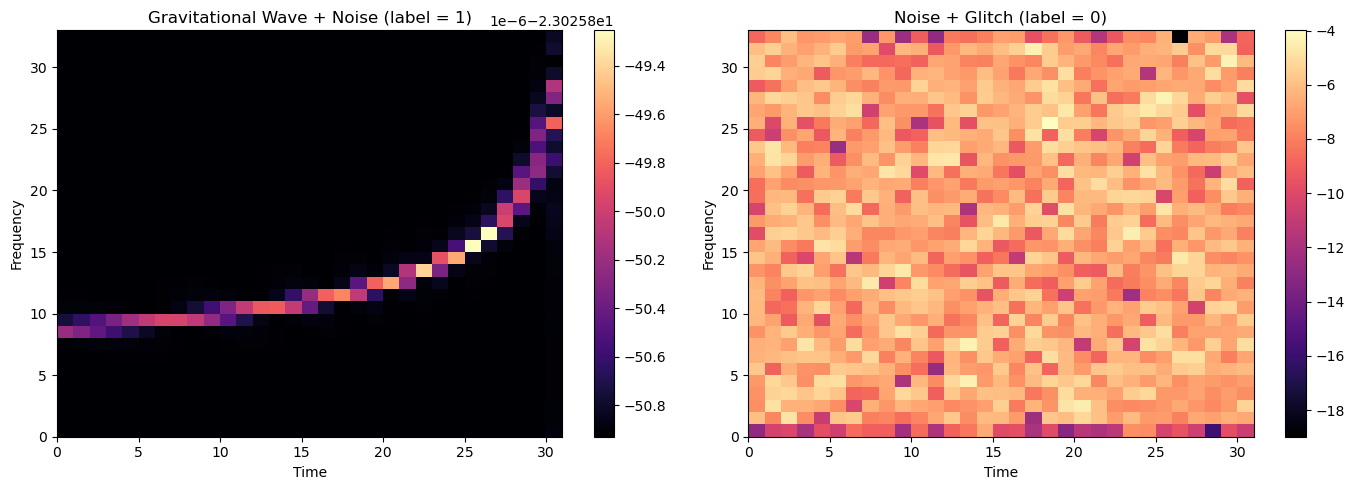

In [ ]:
def get_spectrogram(data):
    # Spectrogram (CNN input)
    f, t, Sxx = signal.spectrogram(data, fs=1024, nperseg=64, noverlap=32)
    return np.log(Sxx + 1e-10)


# -----------------------------
# Example: What the CNN "sees"
# -----------------------------

# 1. Gravitational wave signal (label = 1)
gw_signal = generate_gw_signal()
gw_spec = get_spectrogram(gw_signal)

# 2. Non-gravitational-wave signal (label = 0)
noise = generate_realistic_noise()

# add glitch sometimes (to make it realistic)
if np.random.rand() < 0.5:
    noise = noise + generate_glitch()

noise_spec = get_spectrogram(noise)


# -----------------------------
# Plot side by side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GW
im0 = axes[0].pcolormesh(gw_spec, shading='auto', cmap='magma')
axes[0].set_title("Gravitational Wave + Noise (label = 1)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Frequency")
plt.colorbar(im0, ax=axes[0])

# Noise / glitch
im1 = axes[1].pcolormesh(noise_spec, shading='auto', cmap='magma')
axes[1].set_title("Noise + Glitch (label = 0)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Frequency")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# Block 4: CNN Arquitechture (with Dropout)

In [ ]:

class CNN(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU()
        )
        
        # Dinamically compute flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_shape[0], input_shape[1])
            conv_out = self.conv(dummy)
            self.flatten_size = conv_out.view(1, -1).shape[1]
        
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

# --- DYNAMIC SHAPE DETECTION ---
test_sig = generate_gw_signal()
test_spec = get_spectrogram(test_sig)

# Automatically detect shape (ej. 33, 61, 1)
shape_real = (test_spec.shape[0], test_spec.shape[1], 1) 

model = CNN(shape_real)
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Block 5: Dataset creation + Training / Evaluation functions

In [ ]:
num_samples = 100000 
X, y = [], []

for i in range(num_samples):

    label = np.random.choice([0, 1])

    if label == 1:
        raw = generate_gw_signal()

    else:
        base_noise = generate_realistic_noise()

        if np.random.rand() < 0.5:
            glitch = generate_glitch()
            raw = base_noise + glitch
        else:
            raw = base_noise

    spec = get_spectrogram(raw)

    X.append(spec)
    y.append(label)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)
# Shuffle data
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

# CNN expects 4D inputs (samples, height, width, channels)
X = X[..., np.newaxis]

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Normalization
mean = X_train.mean()
std = X_train.std() + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_t   = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

print(f"Dataset ready: {X.shape[0]} images {X.shape[1]}x{X.shape[2]}")

# Training function
def train_one_epoch(model, device, dataloader, optimizer, criterion):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Evaluation function
def evaluate(model, device, dataloader, criterion=None):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)

            if criterion is not None:
                loss = criterion(outputs, y_batch)
                running_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total

    if criterion is not None:
        loss = running_loss / total
        return loss, acc
    else:
        return acc

Dataset ready: 100000 images 33x31


# Block 6: Training (Early Stopping)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print('Using device: ', device)

model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 50
patience = 10
best_val_loss = float('inf')
counter = 0

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

import copy

best_model = copy.deepcopy(model.state_dict())
counter = 0

for epoch in range(epochs):
    
    train_loss, train_acc = train_one_epoch(
        model, device, train_loader, optimizer, criterion
    )

    val_loss, val_acc = evaluate(
        model, device, val_loader, criterion
    )

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_model)

# Final Test evaluation
model.eval()
correct = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct += (preds == y_batch).sum().item()

test_acc = correct / len(X_test_t)
print(f"\n Final test accuracy: {test_acc*100:.2f}%")

Using device:  mps
Epoch 1: loss=0.4847, val_loss=0.4776, acc=0.7507, val_acc=0.7519
Epoch 2: loss=0.4806, val_loss=0.4791, acc=0.7514, val_acc=0.7519
Epoch 3: loss=0.4804, val_loss=0.4783, acc=0.7514, val_acc=0.7519
Epoch 4: loss=0.4800, val_loss=0.4775, acc=0.7514, val_acc=0.7519
Epoch 5: loss=0.4801, val_loss=0.4765, acc=0.7514, val_acc=0.7519
Epoch 6: loss=0.4801, val_loss=0.4768, acc=0.7514, val_acc=0.7519
Epoch 7: loss=0.4793, val_loss=0.4768, acc=0.7514, val_acc=0.7519
Epoch 8: loss=0.4796, val_loss=0.4767, acc=0.7514, val_acc=0.7519
Epoch 9: loss=0.4796, val_loss=0.4765, acc=0.7514, val_acc=0.7519
Epoch 10: loss=0.4795, val_loss=0.4766, acc=0.7514, val_acc=0.7519
Epoch 11: loss=0.4793, val_loss=0.4777, acc=0.7514, val_acc=0.7519
Epoch 12: loss=0.4791, val_loss=0.4766, acc=0.7514, val_acc=0.7519
Epoch 13: loss=0.4792, val_loss=0.4765, acc=0.7514, val_acc=0.7519
Epoch 14: loss=0.4792, val_loss=0.4765, acc=0.7514, val_acc=0.7519
Epoch 15: loss=0.4791, val_loss=0.4768, acc=0.7514, 

# Block 7: Visualization of learning curves

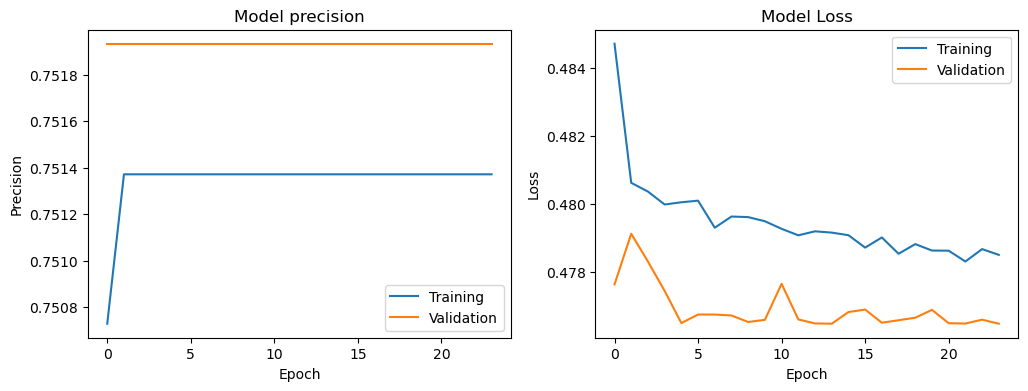

In [ ]:
import matplotlib.pyplot as plt

# Visualize the accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training')
plt.plot(history['val_accuracy'], label='Validation')
plt.title('Model precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# Graficamos la pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Block 8: Evaluation with ROC curve

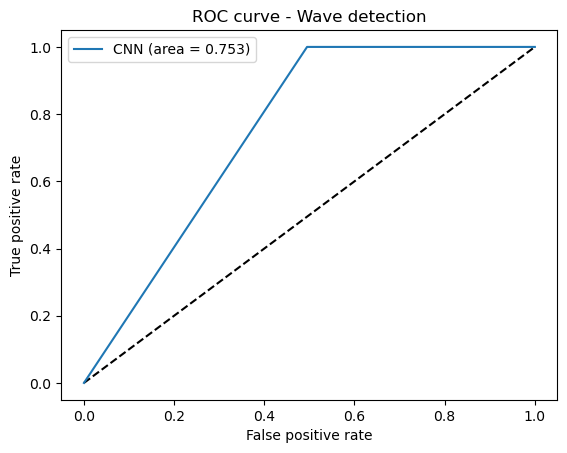

In [ ]:
from sklearn.metrics import roc_curve, auc

model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        y_pred.extend(probs.cpu().numpy())

y_pred = np.array(y_pred).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = auc(fpr, tpr)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='CNN (area = {:.3f})'.format(auc_score))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - Wave detection')
plt.legend(loc='best')
plt.show()

# Block 9: SNR sensitivity test

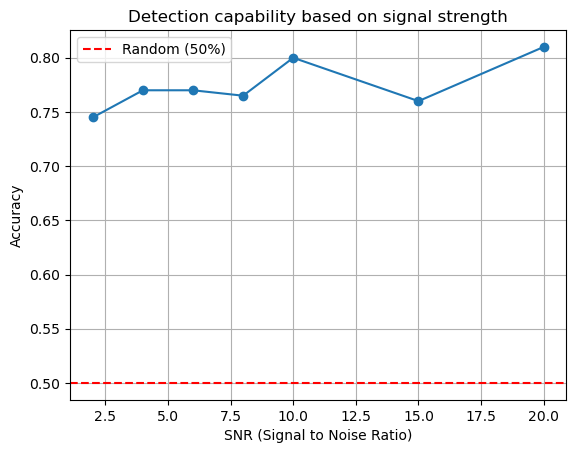

In [ ]:
def evaluate_specific_SNR(model, snr_target):
    X_snr = []
    y_snr = []
    
    for _ in range(200):
        has_sig = np.random.choice([0, 1])
        
        if has_sig:
            sig = generate_waveform()
            noise = generate_realistic_noise()
            raw = noise + snr_target * sig
        else:
            base_noise = generate_realistic_noise()
            if np.random.rand() < 0.5:
                raw = base_noise + generate_glitch()
            else:
                raw = base_noise
        
        X_snr.append(get_spectrogram(raw))
        y_snr.append(has_sig)
    
    X_snr = np.array(X_snr)[..., np.newaxis]
    X_snr = (X_snr - mean) / std
    
    X_snr_t = torch.tensor(X_snr, dtype=torch.float32).permute(0,3,1,2).to(device)
    y_snr_t = torch.tensor(y_snr, dtype=torch.float32).unsqueeze(1).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(X_snr_t)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct = (preds == y_snr_t).sum().item()
    
    return correct / len(y_snr)

# Define the SNR levels we want to test (from very difficult to very easy)
snr_levels = [2, 4, 6, 8, 10, 15, 20]
precisions = [evaluate_specific_SNR(model, s) for s in snr_levels]

plt.figure()
plt.plot(snr_levels, precisions, 'o-')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random (50%)')
plt.xlabel('SNR (Signal to Noise Ratio)')
plt.ylabel('Accuracy')
plt.title('Detection capability based on signal strength')
plt.grid(True)
plt.legend()
plt.show()

Evaluating model sensitivity by SNR level...
Precision for SNR 2: 72.5%
Precision for SNR 4: 75.0%
Precision for SNR 6: 76.0%
Precision for SNR 8: 75.0%
Precision for SNR 10: 76.0%
Precision for SNR 15: 74.0%
Precision for SNR 20: 75.0%


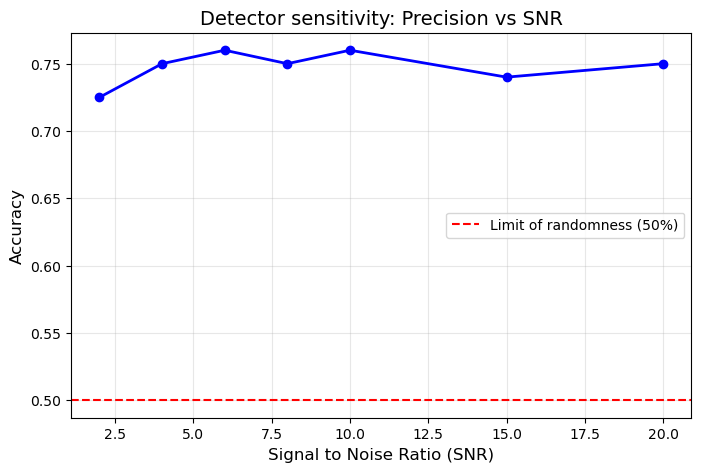

In [ ]:
print("Evaluating model sensitivity by SNR level...")
precisions = []

for s in snr_levels:
    acc = evaluate_specific_SNR(model, s)
    precisions.append(acc)
    print(f"Precision for SNR {s}: {acc*100:.1f}%")

# Performance visualization
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, precisions, marker='o', linestyle='-', color='b', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Limit of randomness (50%)')
plt.title('Detector sensitivity: Precision vs SNR', fontsize=14)
plt.xlabel('Signal to Noise Ratio (SNR)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Block 10: Generalization Test

In [ ]:
def test_generalization(model):
    snr = 15
    
    sig = generate_waveform()
    noise = generate_realistic_noise()
    data = noise + snr * sig
    
    spec = get_spectrogram(data)[np.newaxis, ..., np.newaxis]
    spec = (spec - mean) / std
    
    model.eval()
    with torch.no_grad():
        spec_t = torch.tensor(spec, dtype=torch.float32).permute(0,3,1,2).to(device)
        logits = model(spec_t)
        prob = torch.sigmoid(logits).cpu().numpy()
    
    print(f"Probability of being a GW signal: {prob[0][0]:.4f}")


print("Running generalization test...")
test_generalization(model)

Running generalization test...
Probability of being a GW signal: 0.6692


In [ ]:
print("\n--- Test with new signal (Linear Chirp + realistic noise) ---")

t_gen = np.linspace(0, 1, 1024)

sig_lineal = signal.chirp(t_gen, f0=40, f1=200, t1=1, method='linear')
sig_lineal = sig_lineal / (np.std(sig_lineal) + 1e-8)

noise = generate_realistic_noise()
snr_test = 12

data_gen = noise + snr_test * sig_lineal

spec_gen = get_spectrogram(data_gen)[np.newaxis, ..., np.newaxis]
spec_gen = (spec_gen - mean) / std

model.eval()
with torch.no_grad():
    spec_t = torch.tensor(spec_gen, dtype=torch.float32).permute(0,3,1,2).to(device)
    logits = model(spec_t)
    prob = torch.sigmoid(logits).cpu().numpy()

print(f"Result: probability of GW = {prob[0][0]*100:.2f}%")

if prob[0][0] > 0.5:
    print("Conclusion: Model generalizes to new morphologies")
else:
    print("Conclusion: Model does NOT generalize")


--- Test with new signal (Linear Chirp + realistic noise) ---
Result: probability of GW = 0.00%
Conclusion: Model does NOT generalize


# Block 11: Visual comparison (Generalization)

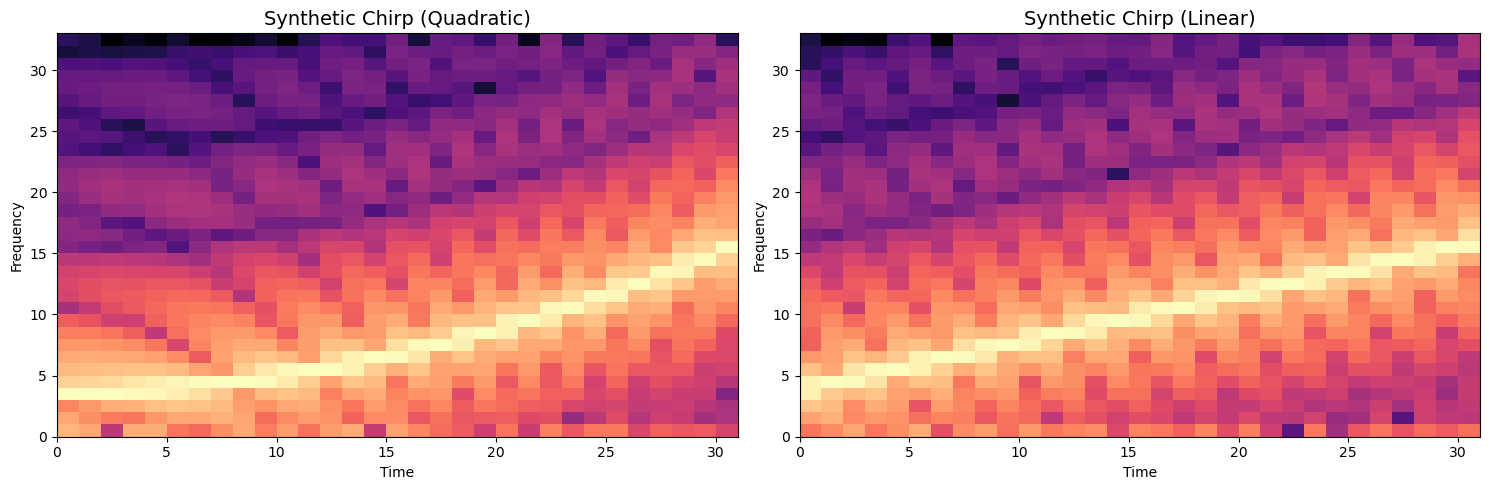

In [ ]:
def compare_morphologies():
    t = np.linspace(0, 1, 1024)
    
    # Signals
    sig_quad = signal.chirp(t, f0=50, f1=250, t1=1, method='quadratic')
    sig_lin  = signal.chirp(t, f0=50, f1=250, t1=1, method='linear')
    
    # Normalize
    sig_quad = sig_quad / (np.std(sig_quad) + 1e-8)
    sig_lin  = sig_lin  / (np.std(sig_lin)  + 1e-8)
    
    # Add realistic noise
    noise1 = generate_realistic_noise()
    noise2 = generate_realistic_noise()
    
    data_quad = noise1 + 10 * sig_quad
    data_lin  = noise2 + 10 * sig_lin
    
    # Spectrograms
    spec_quad = get_spectrogram(data_quad)
    spec_lin  = get_spectrogram(data_lin)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.pcolormesh(spec_quad, shading='auto', cmap='magma')
    ax1.set_title('Synthetic Chirp (Quadratic)', fontsize=14)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Frequency')
    
    ax2.pcolormesh(spec_lin, shading='auto', cmap='magma')
    ax2.set_title('Synthetic Chirp (Linear)', fontsize=14)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

compare_morphologies()